# Building a Quantitative Trading Strategy
## Part 1: Machine Learning Model in PyTorch

This notebook demonstrates how to build a predictive model for cryptocurrency trading
using PyTorch. We'll create an autoregressive (AR) model that predicts future log returns
based on historical price patterns.

## Trading System Overview

Our quantitative trading system follows a three-step pipeline:

```
y_hat = model(x)      # Step 1: Generate predictions
orders = strategy(y_hat)  # Step 2: Convert to trading signals
execute(orders)       # Step 3: Execute trades
```

This notebook focuses on **Step 1**: building a regression model that predicts
future log returns for BTCUSDT.

---
## 1. Environment Setup

### 1.1 Import Libraries

#### Core Data & Numerical Libraries

In [1]:
import polars as pl                         # High-performance DataFrame library
import numpy as np                          # Numerical computing
from datetime import datetime, timedelta    # Date/time utilities
import random                               # Random number generation

#### Machine Learning Libraries

In [2]:

import torch                                # PyTorch deep learning framework
import torch.nn as nn                       # Neural network modules
import torch.optim as optim                 # Optimization algorithms

#### Quant Research Library
Our custom library containing utilities for model training, backtesting, and analysis.
Located in `src/quant_research/`

In [3]:
from src.quant_research import (
    # Reproducibility
    set_seed,
    # Data loading
    load_ohlc_timeseries_range,
    load_timeseries_range,
    # Feature engineering
    add_lags,
    add_log_return_features,
    # Model utilities
    timeseries_train_test_split,
    print_model_info,
    total_model_params,
    benchmark_reg_model,
    benchmark_linear_models,
    learn_model_trades,
    add_tx_fees_log,
    # Analysis
    auto_reg_corr_matrx,
    sharpe_annualization_factor,
    eval_model_performance,
    # Visualization
    plot_static_timeseries,
    plot_dyn_timeseries,
    plot_column,
    plot_distribution,
)

#### Visualization

In [4]:

import altair as alt                        # Interactive plotting library

#### Market Data Sources
Exchange connector for downloading historical trade data.
Located in `src/connectors/`

In [5]:

from src.connectors.binance import (
    download_date_range,
    download_trades,
    MAKER_FEE,
    TAKER_FEE,
)

### 1.2 Reproducibility

Setting a global seed ensures deterministic results across runs.
This is critical for:
- Debugging models reliably
- Comparing strategies fairly
- Validating backtesting results

In [6]:

set_seed(42)

### 1.3 Display Configuration

Configure Polars for better notebook readability.

In [7]:

pl.Config.set_tbl_width_chars(200)      # Wider tables
pl.Config.set_fmt_str_lengths(100)      # Longer strings
pl.Config.set_tbl_cols(-1)              # Show all columns

polars.config.Config

---
## 2. Configuration Parameters

### 2.1 Trading Parameters

In [8]:

# Trading pair symbol (e.g., BTCUSDT, ETHUSDT)
sym = 'BTCUSDT'

# Time interval for OHLC bars
# Options: '1m', '5m', '15m', '1h', '4h', '12h', '1d'
time_interval = '1h'

# Maximum number of autoregressive lags
# The model uses the previous `max_lags` observations as features
max_lags = 4

# Forecast horizon in time steps
# A value of 1 means predicting the next bar
forecast_horizon = 1

### 2.2 Performance Metrics Configuration

Sharpe ratio annualization factor makes Sharpe ratios comparable across
different time frequencies.

Formula: $\text{Annualized Sharpe} = \text{Sharpe} \times \sqrt{\text{periods per year}}$

In [9]:

annualized_rate = sharpe_annualization_factor(
    time_interval,
    365,  # Trading days per year (crypto trades 24/7)
    24    # Periods per day for hourly data
)

---
## 3. Data Acquisition

We download historical trade data from Binance's public data repository.
Data is cached as parquet files in `data/cache/` for faster subsequent access.

### 3.1 Download Historical Data

In [10]:

# Define the date range for our analysis
start_date = datetime(2024, 1, 1, 0, 0)
end_date = datetime(2026, 3, 30, 0, 0)

# Download trade data for the specified range
# Files are cached in data/cache/ as parquet files
download_date_range(sym, start_date, end_date)

### 3.2 Load OHLC Time Series

Convert raw trades into OHLC (Open, High, Low, Close) bars.
This aggregates tick-level data into regular time intervals.

In [11]:
ts = load_ohlc_timeseries_range(sym, time_interval, start_date, end_date)
ts

Loading BTCUSDT: 100%|██████████| 820/820 [03:30<00:00,  3.89day/s]


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2024-01-01 00:00:00,42314.0,42603.2,42289.6,42503.5
2024-01-01 01:00:00,42503.5,42832.0,42462.0,42647.9
2024-01-01 02:00:00,42647.9,42676.9,42530.0,42620.4
2024-01-01 03:00:00,42620.5,42630.0,42270.0,42369.8
2024-01-01 04:00:00,42369.8,42439.8,42235.2,42436.6
…,…,…,…,…
2026-03-30 19:00:00,66620.6,66640.0,66200.1,66516.0
2026-03-30 20:00:00,66515.9,66662.6,66488.7,66614.9
2026-03-30 21:00:00,66614.9,66973.5,66550.0,66770.6


### 3.3 Custom Aggregations

You can also load time series with custom aggregations.
Example: Calculate the median price per interval.

In [12]:
load_timeseries_range(
    sym,
    time_interval,
    start_date,
    end_date,
    pl.col('price').quantile(0.5).alias('price_median')
)

Loading BTCUSDT: 100%|██████████| 820/820 [03:41<00:00,  3.71day/s]


datetime,price_median
datetime[μs],f64
2024-01-01 00:00:00,42466.3
2024-01-01 01:00:00,42702.4
2024-01-01 02:00:00,42596.8
2024-01-01 03:00:00,42430.0
2024-01-01 04:00:00,42350.3
…,…
2026-03-30 19:00:00,66358.7
2026-03-30 20:00:00,66597.4
2026-03-30 21:00:00,66830.1


### 3.4 Visualize Price Data

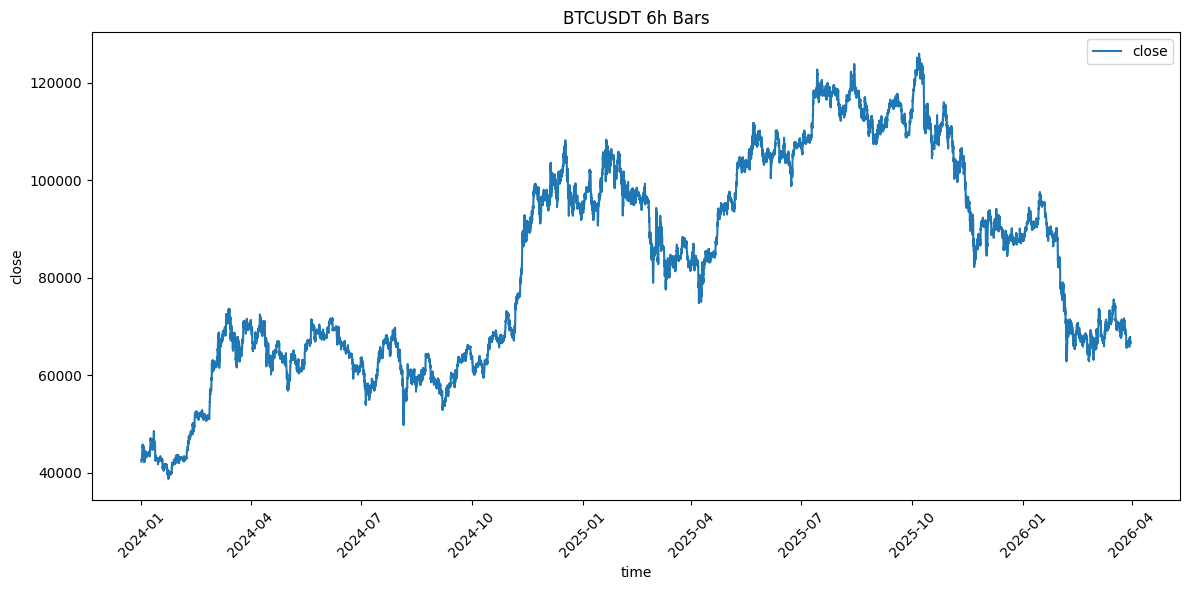

alt.Chart(...)

In [35]:
# Static chart (faster rendering)
plot_static_timeseries(ts, sym, 'close', time_interval)

# Interactive chart with vegafusion backend
alt.data_transformers.enable("vegafusion")
plot_dyn_timeseries(ts, sym, 'close', time_interval)

---
## 4. Feature Engineering

### 4.1 Understanding Log Returns

Log returns are the natural logarithm of price ratios. They have several
advantages over simple returns:

1. **Time additivity**: $\log(P_t / P_0) = \sum_{i=1}^{t} \log(P_i / P_{i-1})$
2. **Symmetry**: A +10% gain and -10% loss have symmetric log returns
3. **Normality**: Log returns are approximately normally distributed

**Mathematical Definition:**

$$r_t = \log\left(\frac{P_t}{P_{t-1}}\right) = \log(P_t) - \log(P_{t-1})$$

In [36]:
# Example: Calculate different return types
price_time_series = pl.DataFrame({'price': [100.0, 120.0, 100.0]})
plot_column(price_time_series, 'price')

# Compare different return calculations
price_time_series.with_columns(
    # Price difference (absolute change)
    pl.col('price').diff().alias('delta'),
    # Simple return (percentage change)
    ((pl.col('price') - pl.col('price').shift()) / pl.col('price').shift()).alias('return'),
    # Log return (our preferred measure)
    (pl.col('price') / pl.col('price').shift()).log().alias('log_return'),
)

price,delta,return,log_return
f64,f64,f64,f64
100.0,null,null,null
120.0,20.0,0.2,0.182322
100.0,-20.0,-0.166667,-0.182322


### 4.2 Create Target Variable

Our target is the future log return - what we want to predict.
For a 1-step forecast horizon, this is the log return of the next bar.

In [37]:
ts = ts.with_columns(
    (pl.col('close') / pl.col('close').shift(forecast_horizon)).log().alias('close_log_return')
)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-01-01 05:00:00,42436.6,42440.0,42207.9,42272.6,null,0.001575,-0.005897,-0.000645,0.003392
2024-01-01 06:00:00,42272.6,42461.3,42239.1,42423.3,0.003559,-0.003872,0.001575,-0.005897,-0.000645
2024-01-01 07:00:00,42423.4,42536.0,42421.7,42527.0,0.002441,0.003559,-0.003872,0.001575,-0.005897
2024-01-01 08:00:00,42527.1,42597.3,42489.4,42588.2,0.001438,0.002441,0.003559,-0.003872,0.001575
2024-01-01 09:00:00,42588.2,42734.2,42570.0,42688.8,0.002359,0.001438,0.002441,0.003559,-0.003872
…,…,…,…,…,…,…,…,…,…
2026-03-30 19:00:00,66620.6,66640.0,66200.1,66516.0,-0.001571,-0.002767,-0.00787,-0.003813,-0.002549
2026-03-30 20:00:00,66515.9,66662.6,66488.7,66614.9,0.001486,-0.001571,-0.002767,-0.00787,-0.003813
2026-03-30 21:00:00,66614.9,66973.5,66550.0,66770.6,0.002335,0.001486,-0.001571,-0.002767,-0.00787


### 4.3 Create Lagged Features

We use lagged log returns as features for our autoregressive model.

**AR(n) Model:**
$$\hat{y}_t = \sum_{i=1}^{n} w_i \cdot r_{t-i} + b$$

Where:
- $\hat{y}_t$ is the predicted return at time $t$
- $r_{t-i}$ is the log return at lag $i$
- $w_i$ are the learned weights
- $b$ is the bias term

In [38]:
# Manual lag creation (for understanding)
target = 'close_log_return'
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon * 1).alias(f'{target}_lag_1'),
    lr.shift(forecast_horizon * 2).alias(f'{target}_lag_2'),
    lr.shift(forecast_horizon * 3).alias(f'{target}_lag_3'),
    lr.shift(forecast_horizon * 4).alias(f'{target}_lag_4'),
)
ts

# Using the library function (recommended)
ts = add_lags(ts, target, max_lags, forecast_horizon)
ts

# Remove rows with null values (from lagging)
ts = ts.drop_nulls()

### 4.4 Analyze Feature Distributions

In [39]:
# Distribution of log returns (should be approximately normal)
plot_distribution(ts, target, n_bins=100)

# Distribution of close prices
plot_distribution(ts, 'close', n_bins=100)

alt.Chart(...)

---
## 5. Model Architecture

### 5.1 Linear Model Definition

We start with a simple linear model (equivalent to linear regression).
This is an AR(n) model where n is the number of lagged features.

**Architecture:**
$$\hat{y} = W \cdot x + b$$

Where:
- $W \in \mathbb{R}^{1 \times n}$ is the weight matrix
- $x \in \mathbb{R}^n$ is the input vector (lagged returns)
- $b \in \mathbb{R}$ is the bias term

In [40]:
class LinearModel(nn.Module):
    """
    Simple linear regression model for time series prediction.

    This is equivalent to an AR(n) (autoregressive) model where n
    is the number of input features (lags).

    The learned weights can be interpreted as AR coefficients:
    - Negative weights suggest mean reversion
    - Positive weights suggest momentum
    """

    def __init__(self, input_features: int):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_features, 1)  # Single output

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)

### 5.2 Model Complexity Analysis

It's important to understand the model's parameter count relative
to the training data size to avoid overfitting.

In [41]:
input_features = 1
linear_model = LinearModel(input_features)

# Display model information
print_model_info(linear_model, "Linear Model")
print(f"Total parameters: {total_model_params(linear_model)}")

# For a linear model with 1 feature: y = w * x + b (2 parameters)


Linear Model

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2

Total parameters: 2


---
## 6. Training Pipeline

### 6.1 Train/Test Split

**Critical:** We use time-based splitting, not random splitting.
This respects the temporal nature of financial data and prevents look-ahead bias.

```
|-------- Training Data --------||-- Test Data --|
t=0                              t=split         t=end
```

In [42]:
features = ['close_log_return_lag_1']
target = 'close_log_return'
test_size = 0.25

# Calculate split index
split_idx = int(len(ts) * (1 - test_size))
print(f"Total samples: {len(ts)}")
print(f"Training samples: {split_idx}")
print(f"Test samples: {len(ts) - split_idx}")

# Split the data
ts_train, ts_test = ts[:split_idx], ts[split_idx:]

Total samples: 19670
Training samples: 14752
Test samples: 4918


### 6.2 Prepare Tensors

Convert Polars DataFrames to PyTorch tensors.

In [43]:
X_train = torch.tensor(ts_train[features].to_numpy(), dtype=torch.float32)
X_test = ts_test[features].to_torch().float()
y_train = torch.tensor(ts_train[target].to_numpy(), dtype=torch.float32).reshape(-1, 1)
y_test = torch.tensor(ts_test[target].to_numpy(), dtype=torch.float32).reshape(-1, 1)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Using the library function for train/test split
timeseries_train_test_split(ts, features, target, test_size)

X_train shape: torch.Size([14752, 1])
y_train shape: torch.Size([14752, 1])


(tensor([[ 2.3594e-03],
         [ 9.1083e-04],
         [-2.3404e-06],
         ...,
         [-3.9224e-04],
         [ 1.8524e-04],
         [ 1.5487e-03]]),
 tensor([[ 0.0018],
         [ 0.0010],
         [-0.0003],
         ...,
         [ 0.0015],
         [ 0.0023],
         [-0.0004]]),
 tensor([[ 9.1083e-04],
         [-2.3404e-06],
         [-1.0678e-03],
         ...,
         [ 1.8524e-04],
         [ 1.5487e-03],
         [ 1.7771e-03]]),
 tensor([[ 0.0010],
         [-0.0003],
         [-0.0006],
         ...,
         [ 0.0023],
         [-0.0004],
         [ 0.0003]]))

### 6.3 Training with Gradient Descent

We use the Adam optimizer with MSE loss to train our linear model.

**Training Loop:**
1. Forward pass: compute predictions
2. Compute loss
3. Backward pass: compute gradients
4. Update weights

In [44]:
# Hyperparameters
no_epochs = 1000 * 5
lr = 0.0005

# Initialize model, loss, and optimizer
model = LinearModel(len(features))
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

print("\nTraining model...")

for epoch in range(no_epochs):
    # Forward pass
    y_hat = model(X_train)
    loss = criterion(y_hat, y_train)

    # Backward pass
    optimizer.zero_grad()   # Clear old gradients
    loss.backward()         # Compute new gradients
    optimizer.step()        # Update weights

    # Logging
    train_loss = loss.item()
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{no_epochs}], Loss: {train_loss:.6f}")

# Display learned parameters
print("\nLearned parameters:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

# Evaluation on test set
model.eval()
with torch.no_grad():
    y_hat = model(X_test)
    test_loss = criterion(y_hat, y_test)
    print(f"\nTest Loss: {test_loss.item():.6f}, Train Loss: {train_loss:.6f}")


Training model...
Epoch [500/5000], Loss: 0.004733
Epoch [1000/5000], Loss: 0.000087
Epoch [1500/5000], Loss: 0.000028
Epoch [2000/5000], Loss: 0.000028
Epoch [2500/5000], Loss: 0.000028
Epoch [3000/5000], Loss: 0.000028
Epoch [3500/5000], Loss: 0.000028
Epoch [4000/5000], Loss: 0.000028
Epoch [4500/5000], Loss: 0.000028
Epoch [5000/5000], Loss: 0.000028

Learned parameters:
linear.weight:
[[-0.01625161]]
linear.bias:
[6.552103e-05]

Test Loss: 0.000025, Train Loss: 0.000028


---
## 7. Trading Performance Evaluation

### 7.1 Basic Trade Simulation

We convert model predictions into trading signals:
- Positive prediction → Long position (buy)
- Negative prediction → Short position (sell)

**Trade Return:**
$$r_{trade} = \text{sign}(\hat{y}) \times r_{actual}$$

In [45]:
trade_results = pl.DataFrame({
    'y_hat': y_hat.squeeze(),
    'y': y_test.squeeze()
}).with_columns(
    # Check if prediction direction was correct
    (pl.col('y_hat').sign() == pl.col('y').sign()).alias('is_won'),
    # Trading signal (direction)
    pl.col('y_hat').sign().alias('signal'),
).with_columns(
    # Trade return (signal * actual return)
    (pl.col('signal') * pl.col('y')).alias('trade_log_return')
).with_columns(
    # Cumulative equity curve
    pl.col('trade_log_return').cum_sum().alias('equity_curve')
)
trade_results

# Visualize equity curve
plot_column(trade_results, 'equity_curve')

alt.Chart(...)

### 7.2 Performance Metrics

#### Maximum Drawdown

Drawdown measures the peak-to-trough decline in equity.

$$\text{Drawdown}_t = \text{Equity}_t - \max_{s \leq t}(\text{Equity}_s)$$

In [46]:
trade_results = trade_results.with_columns(
    (pl.col('equity_curve') - pl.col('equity_curve').cum_max()).alias('drawdown_log')
)

max_drawdown_log = trade_results['drawdown_log'].min()
drawdown_pct = np.exp(max_drawdown_log) - 1
print(f"Maximum Drawdown: {drawdown_pct:.2%}")

# Example: $1000 equity with this drawdown
equity_peak = 1000
print(f"Max loss from ${equity_peak}: ${equity_peak * drawdown_pct:.2f}")

Maximum Drawdown: -41.45%
Max loss from $1000: $-414.46


#### Win Rate

Percentage of trades where prediction direction was correct.

In [47]:
win_rate = trade_results['is_won'].mean()
print(f"Win Rate: {win_rate:.2%}")

Win Rate: 50.24%


#### Expected Value (EV)

$$EV = P(win) \times \bar{r}_{win} + P(loss) \times \bar{r}_{loss}$$

In [48]:
avg_win = trade_results.filter(pl.col('is_won') == True)['trade_log_return'].mean()
avg_loss = trade_results.filter(pl.col('is_won') == False)['trade_log_return'].mean()
ev = win_rate * avg_win + (1 - win_rate) * avg_loss
print(f"Expected Value per trade: {ev:.6f}")

Expected Value per trade: -0.000086


#### Total Return

In [49]:
total_log_return = trade_results['trade_log_return'].sum()
compound_return = np.exp(total_log_return)
print(f"Total Log Return: {total_log_return:.4f}")
print(f"Compound Return: {compound_return:.2%}")
print(f"Final equity from $1000: ${1000 * compound_return:.2f}")

Total Log Return: -0.4221
Compound Return: 65.57%
Final equity from $1000: $655.70


#### Sharpe Ratio

$$\text{Sharpe} = \frac{E[r]}{\sigma_r} \times \sqrt{\text{annualization factor}}$$

In [50]:
std = trade_results['trade_log_return'].std()
sharpe = ev / std * annualized_rate
print(f"Annualized Sharpe Ratio: {sharpe:.2f}")

# Using library function for comprehensive evaluation
eval_model_performance(y_test, y_hat, features, target, annualized_rate)

Annualized Sharpe Ratio: -1.62


{'features': 'close_log_return_lag_1',
 'target': 'close_log_return',
 'no_trades': 4918,
 'win_rate': 0.5024400162667751,
 'avg_win': 0.0031763860823942843,
 'avg_loss': -0.0033800172729024484,
 'best_trade': 0.03395244851708412,
 'worst_trade': -0.03779428079724312,
 'ev': -8.581786441561891e-05,
 'std': 0.0049651009030640125,
 'total_log_return': -0.4220522940158844,
 'compound_return': np.float64(0.6556997493237603),
 'max_drawdown': -0.5352292656898499,
 'equity_trough': -0.42632800340652466,
 'equity_peak': 0.1089012399315834,
 'sharpe': np.float64(-1.6177137509282475)}

---
## 8. Model Benchmarking

### 8.1 Single Feature Benchmark

In [51]:
target = 'close_log_return'
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
perf = benchmark_reg_model(ts, features, target, model, annualized_rate, no_epochs=50)
perf

{'features': 'close_log_return_lag_2',
 'target': 'close_log_return',
 'no_trades': 4918,
 'win_rate': 0.5073200488003253,
 'avg_win': 0.0031563352719535896,
 'avg_loss': -0.003402680880257681,
 'best_trade': 0.03416519984602928,
 'worst_trade': -0.03779428079724312,
 'ev': -7.51604858357372e-05,
 'std': 0.004965273663401604,
 'total_log_return': -0.3696393370628357,
 'compound_return': np.float64(0.6909834978398292),
 'max_drawdown': -0.6579668521881104,
 'equity_trough': -0.427187442779541,
 'equity_peak': 0.23077937960624695,
 'sharpe': np.float64(-1.416767030814054),
 'weights': '[-0.02994853]',
 'biases': '5.711425910703838e-05'}

### 8.2 Feature Combination Search

Test all single-feature models to find the best lag.

In [52]:
import itertools

benchmarks = []
feature_pool = [f'{target}_lag_{i}' for i in range(1, max_lags + 1)]
combos = list(itertools.combinations(feature_pool, 1))

for features in combos:
    model = LinearModel(len(features))
    benchmarks.append(benchmark_reg_model(
        ts, list(features), target, model, annualized_rate,
        test_size=test_size, no_epochs=200, loss=nn.L1Loss()
    ))

benchmark = pl.DataFrame(benchmarks)
benchmark.sort('sharpe', descending=True)

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",4918,0.508133,0.003185,-0.003374,0.034165,-0.037794,-0.000041,0.004966,-0.203526,0.815849,-0.463937,-0.256395,0.207542,-0.78002,"""[-0.0298331]""","""6.073477561585605e-05"""
"""close_log_return_lag_4""","""close_log_return""",4918,0.500203,0.003204,-0.003351,0.034165,-0.037794,-0.000072,0.004965,-0.353822,0.702,-0.646735,-0.507365,0.13937,-1.35613,"""[-0.00492296]""","""5.998810593155213e-05"""
"""close_log_return_lag_1""","""close_log_return""",4918,0.507727,0.003135,-0.003425,0.033952,-0.037794,-0.000094,0.004965,-0.463378,0.629155,-0.498471,-0.479101,0.01937,-1.77617,"""[-0.07716406]""","""7.074110908433795e-05"""
"""close_log_return_lag_3""","""close_log_return""",4918,0.496747,0.003203,-0.003352,0.033952,-0.037794,-0.000096,0.004965,-0.47076,0.624527,-0.733143,-0.511915,0.221228,-1.804477,"""[-0.01478079]""","""6.765446596546099e-05"""


### 8.3 Autocorrelation Analysis

Examine the autocorrelation structure to understand feature importance.

In [53]:
auto_reg_corr_matrx(ts, target, max_lags)

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
f64,f64,f64,f64,f64
1.0,-0.009468,-0.002136,-0.007479,0.011695
-0.009468,1.0,-0.009462,-0.002126,-0.007464
-0.002136,-0.009462,1.0,-0.009454,-0.002116
-0.007479,-0.002126,-0.009454,1.0,-0.009444
0.011695,-0.007464,-0.002116,-0.009444,1.0


### 8.4 Equity Curve Visualization

In [54]:
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
model_trades = learn_model_trades(ts, features, target, model, no_epochs=200, loss=nn.L1Loss())
plot_column(model_trades, 'equity_curve')

alt.Chart(...)

---
## 9. Transaction Fees

### 9.1 Impact of Fees

Real trading incurs transaction costs. For each roundtrip trade (open + close),
we pay fees twice.

**Net Return:**
$$r_{net} = r_{gross} + \log(1 - 2 \times \text{fee})$$

In [55]:

maker_fee = 0.0001  # 0.01% (limit orders)
taker_fee = 0.0003  # 0.03% (market orders)

roundtrip_fee_log = np.log(1 - 2 * taker_fee)

model_trades = model_trades.with_columns(pl.lit(roundtrip_fee_log).alias('tx_fee_log'))
model_trades = model_trades.with_columns(
    (pl.col('trade_log_return') + pl.col('tx_fee_log')).alias('trade_log_return_net')
)
model_trades = model_trades.with_columns(
    pl.col('trade_log_return_net').cum_sum().alias('equity_curve_net')
)
model_trades

# Compare equity curves with and without fees
plot_column(model_trades, 'equity_curve_net')
plot_column(model_trades, 'equity_curve')

print(f"Win Rate: {model_trades['is_won'].mean():.2%}")

# Using library function
model_trades = add_tx_fees_log(model_trades, maker_fee, taker_fee)
model_trades

Win Rate: 50.73%


y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net,trade_log_return_net_maker,trade_log_return_net_taker,equity_curve_net_maker,equity_curve_net_taker
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64
0.000012,0.000975,true,1.0,0.000975,0.000975,0.0,-0.0006,0.000375,0.000375,-9.209365,-8.110753,-9.209365,-8.110753
0.000005,-0.000273,false,1.0,-0.000273,0.000702,-0.000273,-0.0006,-0.000873,-0.000498,-9.210613,-8.112001,-18.419979,-16.222754
0.000029,-0.000591,false,1.0,-0.000591,0.000111,-0.000864,-0.0006,-0.001191,-0.001689,-9.210931,-8.112319,-27.63091,-24.335073
0.000066,0.000837,true,1.0,0.000837,0.000948,-0.000027,-0.0006,0.000236,-0.001453,-9.209504,-8.110891,-36.840414,-32.445964
0.000075,-0.001343,false,1.0,-0.001343,-0.000396,-0.001371,-0.0006,-0.001944,-0.003396,-9.211684,-8.113072,-46.052097,-40.559036
…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.000292,-0.001571,false,1.0,-0.001571,-0.337705,-0.565511,-0.0006,-0.002171,-3.286989,-9.211912,-8.113299,-45259.950292,-39861.369505
0.00014,0.001486,true,1.0,0.001486,-0.336219,-0.564025,-0.0006,0.000886,-3.286103,-9.208855,-8.110242,-45269.159146,-39869.479748
0.000105,0.002335,true,1.0,0.002335,-0.333884,-0.561691,-0.0006,0.001734,-3.284369,-9.208006,-8.109393,-45278.367152,-39877.589141


---
## 10. Optimizing Time Horizon

### 10.1 6-Hour Bars

Increasing the time horizon reduces trading frequency and fee impact.

In [56]:

time_interval = '6h'
ts = load_ohlc_timeseries_range(sym, time_interval, start_date, end_date)
ts

no_lags = 3
ts = add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts

target = 'close_log_return'
feature_pool = [f'{target}_lag_{i}' for i in range(1, no_lags + 1)]
benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.HuberLoss())

auto_reg_corr_matrx(ts.drop_nulls(), target, no_lags)

# Try different loss functions
benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.MSELoss())
benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.L1Loss(), test_size=0.3)

# Visualize with fees
features = ['close_log_return_lag_1']
model = LinearModel(len(features))
model_trades = learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
model_trades = add_tx_fees_log(model_trades, maker_fee, taker_fee)
plot_column(model_trades, 'equity_curve')
plot_column(model_trades, 'equity_curve_net_taker')

Benchmarking models: 100%|██████████| 3/3 [00:06<00:00,  2.32s/it]


alt.Chart(...)

---
## 11. Final Model: 12-Hour Forecast

### 11.1 Research with 12h Bars

The 12-hour horizon provides a good balance between signal strength
and transaction cost efficiency.

In [57]:
time_interval = '12h'

no_lags = 4
ts = add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts

# Test different loss functions
benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.MSELoss())
benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.HuberLoss())
benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.L1Loss(), test_size=0.25)

Benchmarking models: 100%|██████████| 7/7 [00:08<00:00,  1.28s/it]


features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",819,0.554335,0.007654,-0.009648,0.054135,-0.060489,-0.000057,0.012772,-0.046882,0.9542,-0.38548,-0.084542,0.300938,-0.41947,"""[-0.03221776 -0.04796737]""","""0.00031387718627229333"""
"""close_log_return_lag_1""","""close_log_return""",819,0.52381,0.008033,-0.009103,0.060053,-0.060489,-0.000127,0.012772,-0.104026,0.901202,-0.429565,-0.243898,0.185667,-0.93079,"""[-0.02518929]""","""0.00026126790908165276"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",819,0.528694,0.007958,-0.009199,0.060053,-0.060489,-0.000128,0.012772,-0.10495,0.90037,-0.364479,-0.243063,0.137874,-0.939054,"""[-0.02714814 -0.04287241]""","""0.0003355998487677425"""
"""close_log_return_lag_3""","""close_log_return""",819,0.499389,0.008087,-0.008997,0.060053,-0.060489,-0.000465,0.012764,-0.381029,0.683158,-0.497472,-0.394101,0.103371,-3.411418,"""[-0.04060465]""","""0.00034923807834275067"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",819,0.531136,0.007499,-0.009725,0.054135,-0.060489,-0.000577,0.01276,-0.472239,0.623604,-0.72584,-0.510489,0.215352,-4.229543,"""[-0.02768344 -0.04435862 -0.03932904]""","""0.0003568851388990879"""
"""close_log_return_lag_2""","""close_log_return""",819,0.526252,0.007566,-0.009627,0.054135,-0.060489,-0.000579,0.012759,-0.474279,0.622333,-0.622262,-0.517638,0.104624,-4.247853,"""[-0.04158839]""","""0.00034680249518714845"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",819,0.507937,0.007726,-0.009385,0.060053,-0.060489,-0.000694,0.012754,-0.568081,0.566612,-0.71631,-0.60633,0.10998,-5.090268,"""[-0.03888016 -0.04090409]""","""0.0003802036226261407"""


### 11.2 Train and Save Best Model

Using 3 lagged features with L1 loss for robustness.

In [60]:
features = ['close_log_return_lag_1']
model = LinearModel(len(features))
model_trades = learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
model_trades = add_tx_fees_log(model_trades, maker_fee, taker_fee)
plot_column(model_trades, 'equity_curve')

alt.Chart(...)

---
## 12. Save Model

Save the trained model weights for use in production.
Weights are stored in `data/models/` directory.

In [61]:
torch.save(model.state_dict(), 'data/models/model_weights.pth')
print("Model saved to data/models/model_weights.pth")

Model saved to data/models/model_weights.pth


---
## Summary

In this notebook, we:

1. **Downloaded and processed** historical trade data from Binance
2. **Engineered features** using lagged log returns
3. **Built a linear AR model** using PyTorch
4. **Trained and evaluated** the model with proper time-series splitting
5. **Analyzed performance** including Sharpe ratio, drawdown, and win rate
6. **Accounted for transaction fees** in our backtest
7. **Optimized the time horizon** to balance signal vs. costs
8. **Saved the model** for use in strategy development (Part 2)

**Next:** In Part 2, we'll use this model to develop a complete trading strategy
with proper position sizing and leverage considerations.